In [1]:
#!/usr/bin/python3.10

Prerequisites: matplotlib, rpy2

# HSMC modelling

## Configuration
### It is assumed that this notebook is being run from StructureAnalysis/sequence_analysis/tutorials

**Import OpenAlea packages**

In [2]:
from openalea.stat_tool import _stat_tool
from openalea.sequence_analysis import (
    _sequence_analysis,
    Estimate
)
from openalea.sequence_analysis.hidden_semi_markov import HiddenSemiMarkov
from openalea.sequence_analysis.simulate import Simulate
from openalea.sequence_analysis.data_transform import Thresholding

from openalea.stat_tool.data_transform import *
from openalea.stat_tool.cluster import Cluster
from openalea.stat_tool.cluster import Transcode, Cluster

import openalea.stat_tool.plot #import DISABLE_PLOT
from openalea.stat_tool.plot import DISABLE_PLOT
DISABLE_PLOT = False

import os

from openalea.stat_tool.output import plot, Plot

plot.DISABLE_PLOT = DISABLE_PLOT

from openalea.stat_tool.plot import get_plotter, mplotlib 

Running cmake --build & --install in /home/jdurand/devlp/Git/openalea/stat_tool/build
Running cmake --build & --install in /home/jdurand/devlp/Git/openalea/sequence_analysis/build


For correct figure rendering

In [3]:
%matplotlib inline

##### Enabling R extensions

In [4]:
%load_ext rpy2.ipython

#####  Place variables in markdown outputs

In [5]:
from IPython.display import Markdown
from IPython.core.magic import register_cell_magic


@register_cell_magic
def markdown(line, cell):
    return Markdown(cell.format(**globals()))

## Loading and preparing data

In [6]:
import sys, os

In [7]:
sys.path

['/home/jdurand/usr/local/openalea',
 '/home/jdurand/miniforge3/envs/statdev/lib/python313.zip',
 '/home/jdurand/miniforge3/envs/statdev/lib/python3.13',
 '/home/jdurand/miniforge3/envs/statdev/lib/python3.13/lib-dynload',
 '',
 '/home/jdurand/miniforge3/envs/statdev/lib/python3.13/site-packages',
 '/home/jdurand/devlp/Git/openalea/sequence_analysis/src/openalea',
 '/home/jdurand/devlp/Git/openalea/stat_tool/src/openalea']

In [8]:
sys.path.append(".." + os.sep + "tutorials")

In [9]:
from pathlib import Path
from openalea.sequence_analysis import __path__ as seq_path
data_path = Path(seq_path[0])
data_path = str(Path.joinpath(data_path.parent.parent.parent.absolute(), "share","data"))


In [10]:
from openalea.sequence_analysis import (get_shared_data, 
                                        Sequences,
                                        _MarkovianSequences)
data_file = "belren1.seq"

seq = Sequences(get_shared_data(data_file))
mseq = _MarkovianSequences(seq)

# Semantics of the observed variable
Type of lateral production (ramification) at the scale of metamer along a growth unit on apple tree trunks
 * 0: latent bud
 * 1: short vegetative proleptic shoot
 * 2: long vegetative proleptic shoot
 * 3: short floral proleptic shoot
 * 4: (usually long, vegetative) sylleptic shoot

# Exploratory analysis

**Print the first sequence in lines**   
`print(mseq[0])` would print in a column.

In [11]:
seq0 = mseq.select_individual([1], True)

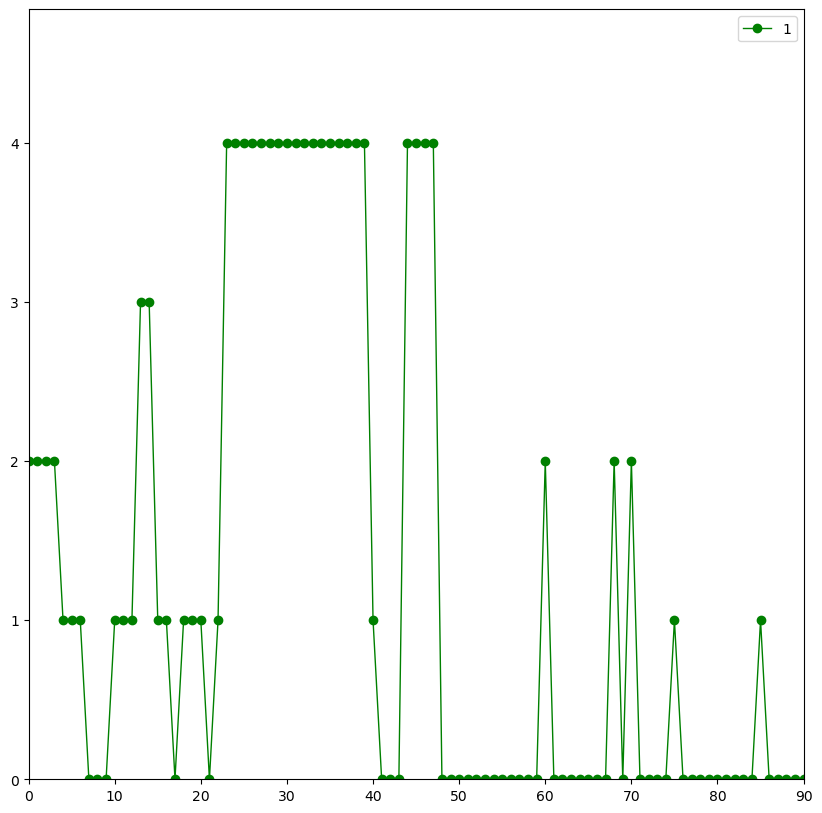

In [12]:
Plot(seq0, ViewPoint="Data")

In [13]:
# Number of sequences
len(mseq)

15

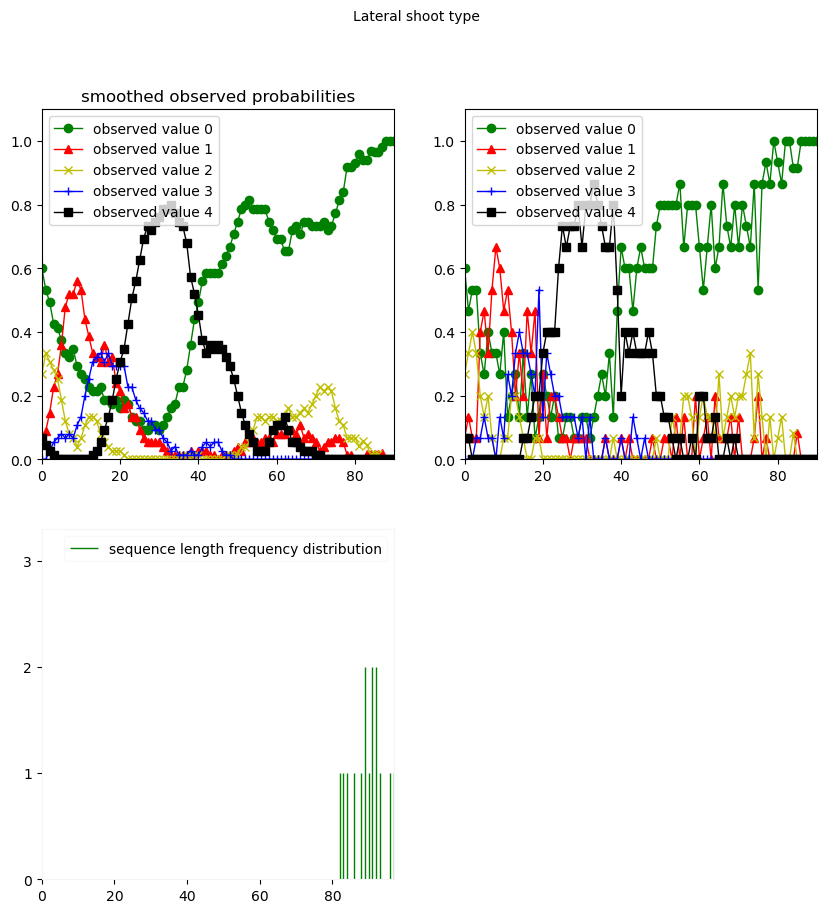

In [14]:
mseq.plot("Intensity", 0, Title="Lateral shoot type")

An exploratory analysis suggests that there is an initial zone with a majority of 0, mixed with 1 and 2; a second zone with a majority of 1, mixed with 0 and 3; a third zone with a majority of 1, mixed with 2; a fourth zone with a majority of 3, mixed with 0 and 1; a fifth zone with a majority of 4, mixed with 0 and a sixth zone with a majority of 0, mixed with 2.

# Estimate Left-Right HSMC with nonparametric emission distributions

nonparametric meant as categorical, saturated model

In [15]:
nb_states = 6

hsmc_est = Estimate(mseq, "HIDDEN_SEMI-MARKOV", "Ordinary", nb_states, "LeftRight", Nbiteration=300)   
print(hsmc_est.display())

iteration 1   log-likelihood for the observed sequences: -1948.95
iteration 2   log-likelihood for the observed sequences: -1287.02
iteration 3   log-likelihood for the observed sequences: -1116.51
iteration 4   log-likelihood for the observed sequences: -1089.17
iteration 5   log-likelihood for the observed sequences: -1072.9
iteration 6   log-likelihood for the observed sequences: -1065.91
iteration 7   log-likelihood for the observed sequences: -1064.37
iteration 8   log-likelihood for the observed sequences: -1064.02
iteration 9   log-likelihood for the observed sequences: -1063.91
iteration 10   log-likelihood for the observed sequences: -1063.85
iteration 11   log-likelihood for the observed sequences: -1063.82
iteration 12   log-likelihood for the observed sequences: -1063.79
iteration 13   log-likelihood for the observed sequences: -1063.73
iteration 14   log-likelihood for the observed sequences: -1063.71
iteration 15   log-likelihood for the observed sequences: -1063.69
itera

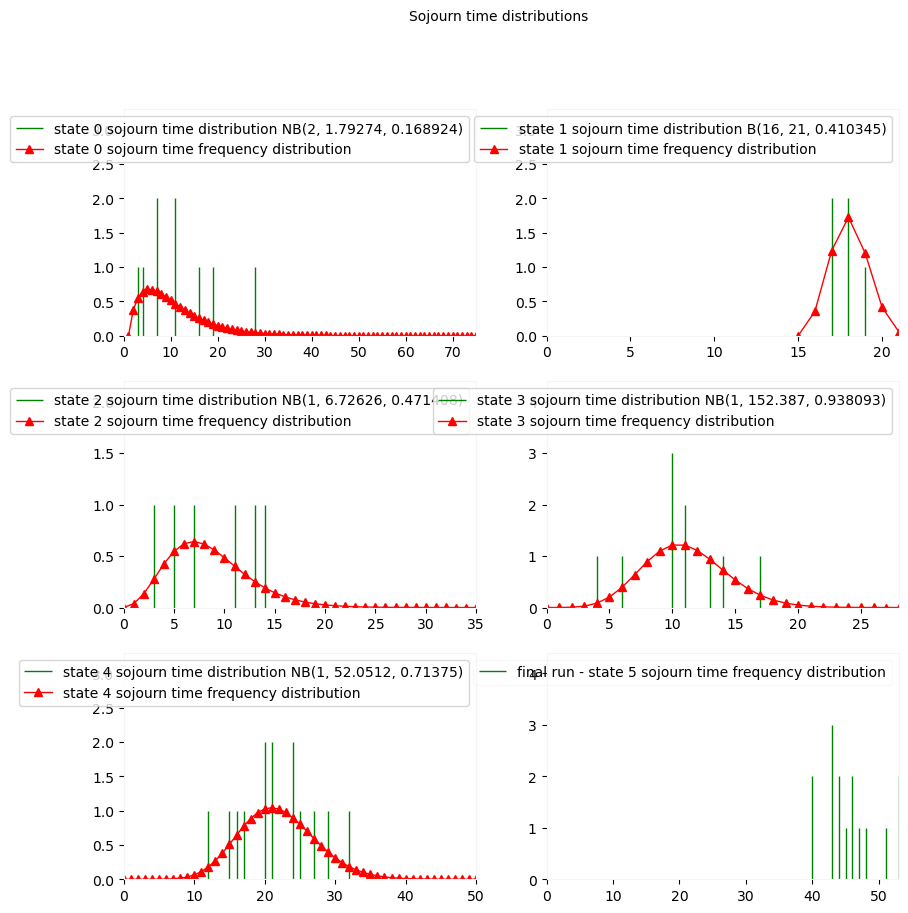

In [16]:
hsmc_est.plot("Sojourn", 0, Title="Sojourn time distributions")

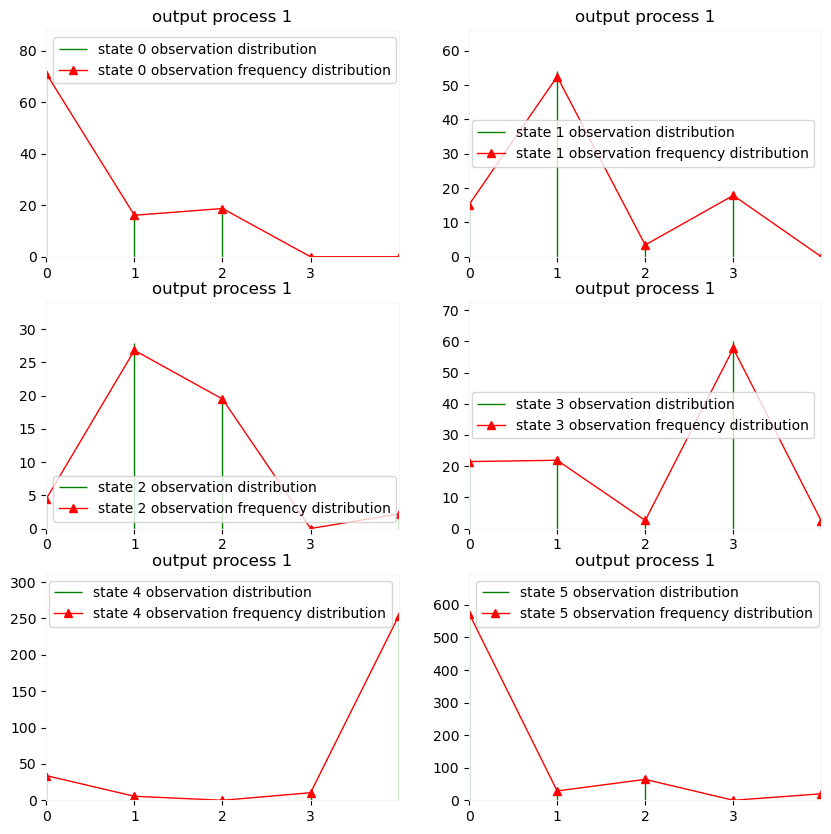

In [17]:
hsmc_est.plot("Observation", 1)

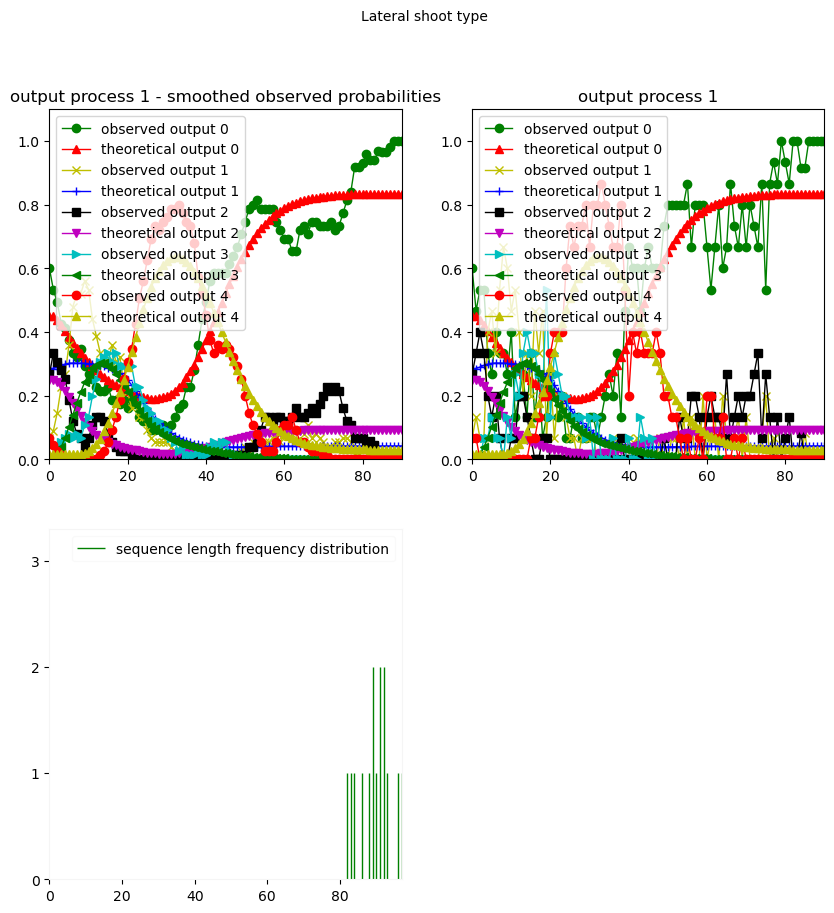

In [18]:
hsmc_est.plot("Intensity", 1, Title="Lateral shoot type")

**Simulate sequences**

# TODO

In [19]:
from openalea.sequence_analysis import Simulate

In [20]:
from openalea.stat_tool.distribution import set_seed
set_seed(0)

Simulate *nb_seq* sequences with length *seq_length*

In [21]:
nb_seq = 30
seq_length = 200
seq = hsmc_est.simulation_nb_sequences(nb_seq, seq_length, True)
assert(len(seq) == nb_seq)
assert(len(seq[0]) == seq_length)
# NB: hsm has 1 output process but simulation includes the hidden state
assert(len(seq[0][1]) == 2)

In [22]:
seq = hsmc_est.simulation_nb_sequences(nb_seq, seq_length, True)

In [23]:
# Print first simulated sequence.
# The first variable is the simulated state
print(seq[0])

[[2, 1], [2, 1], [2, 1], [2, 0], [2, 1], [2, 1], [2, 2], [2, 2], [3, 3], [3, 3], [3, 3], [3, 0], [3, 3], [4, 4], [4, 4], [4, 4], [4, 4], [4, 4], [4, 0], [4, 4], [4, 3], [4, 4], [4, 4], [4, 4], [4, 4], [4, 4], [4, 0], [4, 3], [4, 4], [4, 4], [4, 4], [4, 4], [4, 4], [4, 4], [4, 4], [4, 4], [4, 4], [4, 4], [4, 4], [4, 4], [5, 0], [5, 0], [5, 0], [5, 1], [5, 0], [5, 0], [5, 2], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 4], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 1], [5, 0], [5, 0], [5, 2], [5, 0], [5, 0], [5, 0], [5, 0], [5, 2], [5, 0], [5, 2], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 2], [5, 2], [5, 0], [5, 0], [5, 0], [5, 0], [5, 2], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 1], [5, 0], [5, 0], [5, 0], [5, 0], [5, 1], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 2], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 0], [5, 4],

Discard variable 1 (state)

In [24]:
obs = seq.select_variable([1], keep=False)

## Plotting marginal relative frequencies of data as a function of index

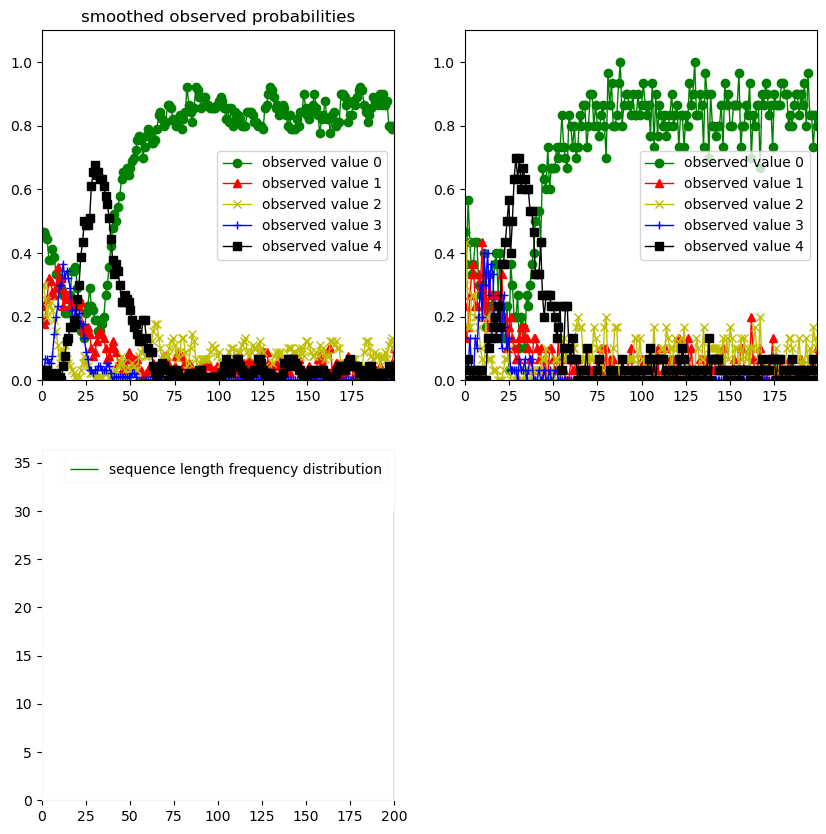

In [25]:
# Variable 1
obs.plot("Intensity", 0)

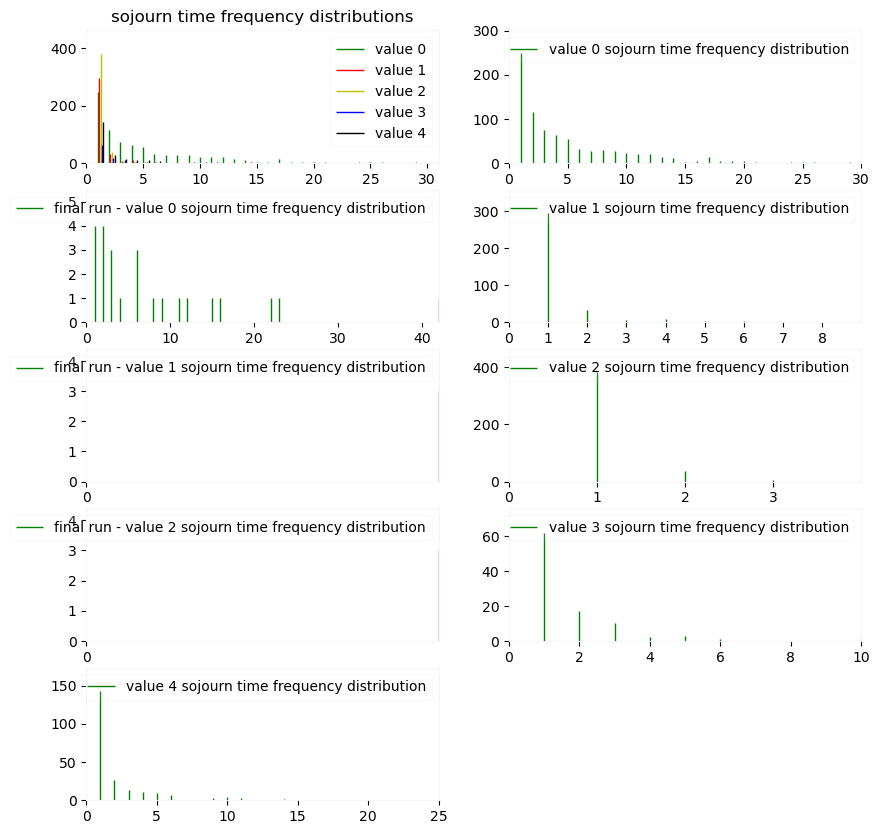

In [26]:
obs.plot("Sojourn", 0)

## HSCM re-estimation

### Reestimate from default initialisation

In [27]:
from openalea.sequence_analysis import Estimate
nb_states = hsmc_est.get_nb_state()

hsmc_est = Estimate(obs, "HIDDEN_SEMI-MARKOV", "Ordinary", nb_states, "Irreducible", Nbiteration=300)   
print(hsmc_est.display())

HIDDEN_SEMI-MARKOV_CHAIN

6 STATES

INITIAL_PROBABILITIES
0.737356     1e-05        0.22795      0.0346649    1e-05        1e-05        

TRANSITION_PROBABILITIES
0            0.495831     1e-05        0.504139     1e-05        1e-05        
1e-05        0            1e-05        1e-05        0.99996      1e-05        
1e-05        1e-05        0            0.99996      1e-05        1e-05        
1e-05        1e-05        1e-05        0            0.842341     0.157629     
1e-05        1e-05        1e-05        1e-05        0            0.99996      
0.999239     8.3811e-05   0.000657299  1e-05        1e-05        0            

recurrent class: states 0 1 2 3 4 5

time up to the first occurrence of state 0 distribution
mean: 120.614   median: 0   mode: 0
variance: 47645.5   standard deviation: 218.278   lower quartile: 0   upper quartile: 255

time up to the first occurrence of state 0 frequency distribution - sample size: 22
mean: 0   median: 0   mode: 0
variance: 0   standard devia

## Plotting marginal relative frequencies of data and predicted probabilities as a function of index

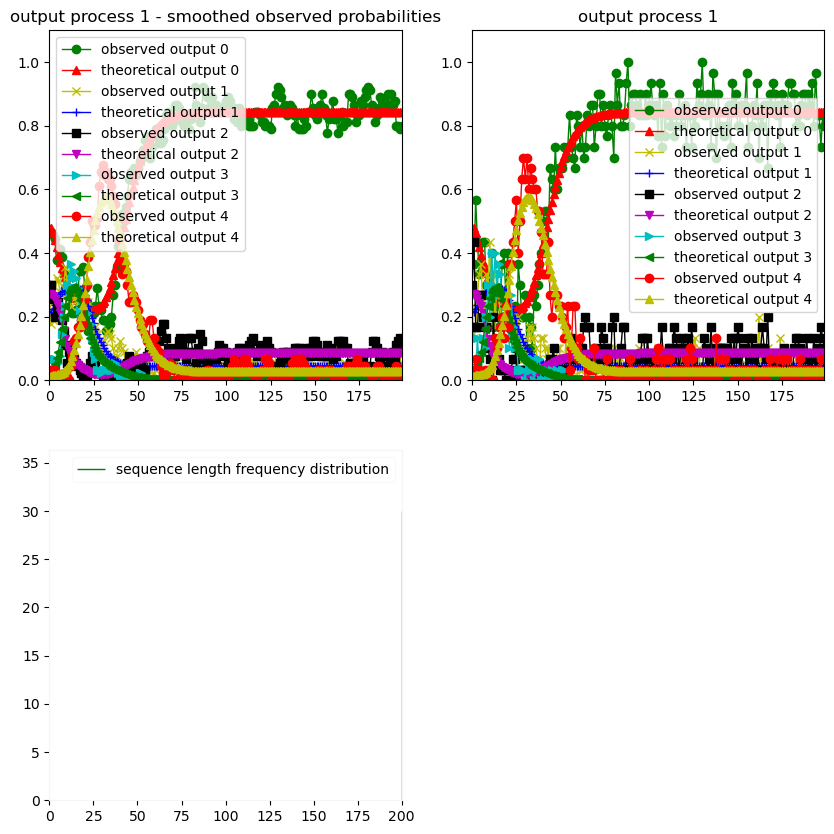

In [28]:
hsmc_est.plot("Intensity", 1)

## Observation (i.e., emission) distributions

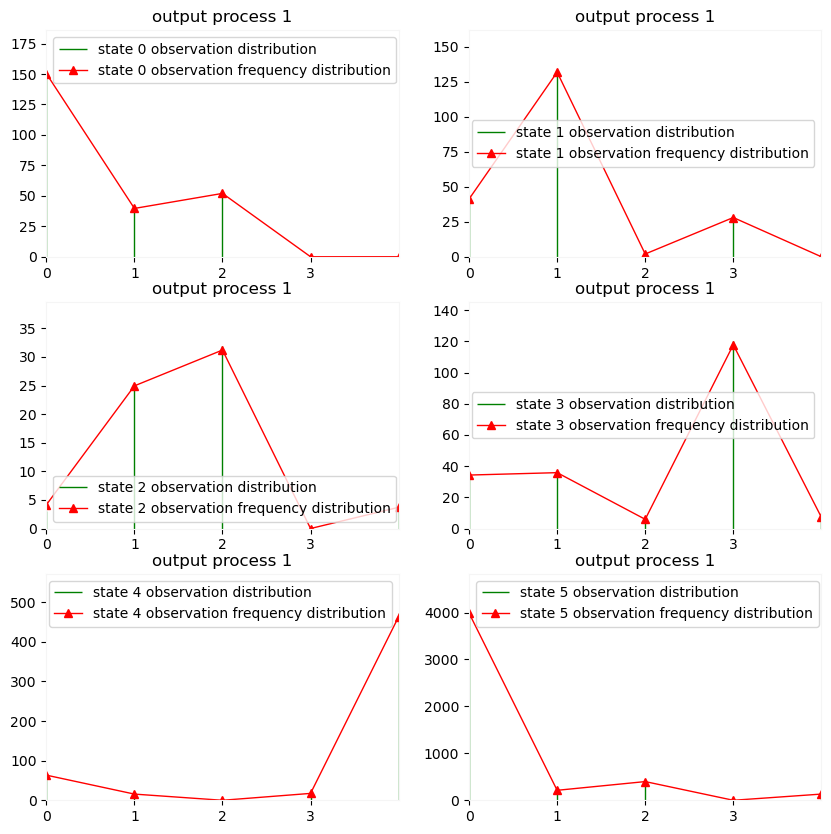

In [29]:
hsmc_est.plot("Observation", 1)


This continues as before: empirical and predicted statistics

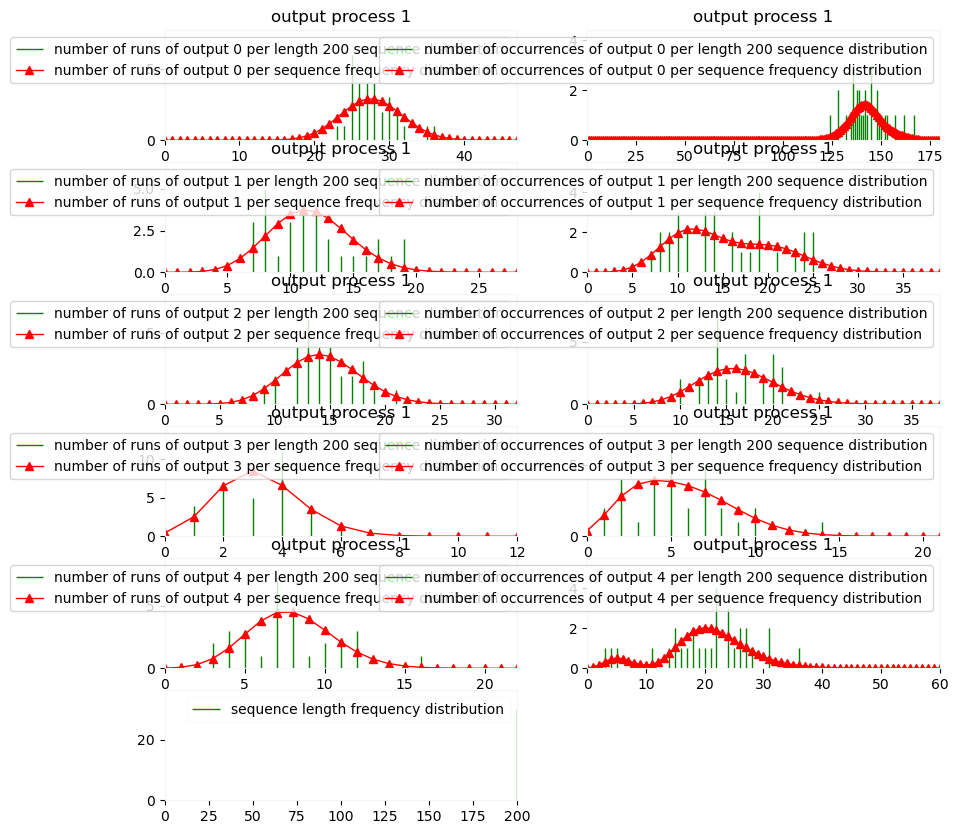

In [30]:
hsmc_est.plot("Counting", 1)


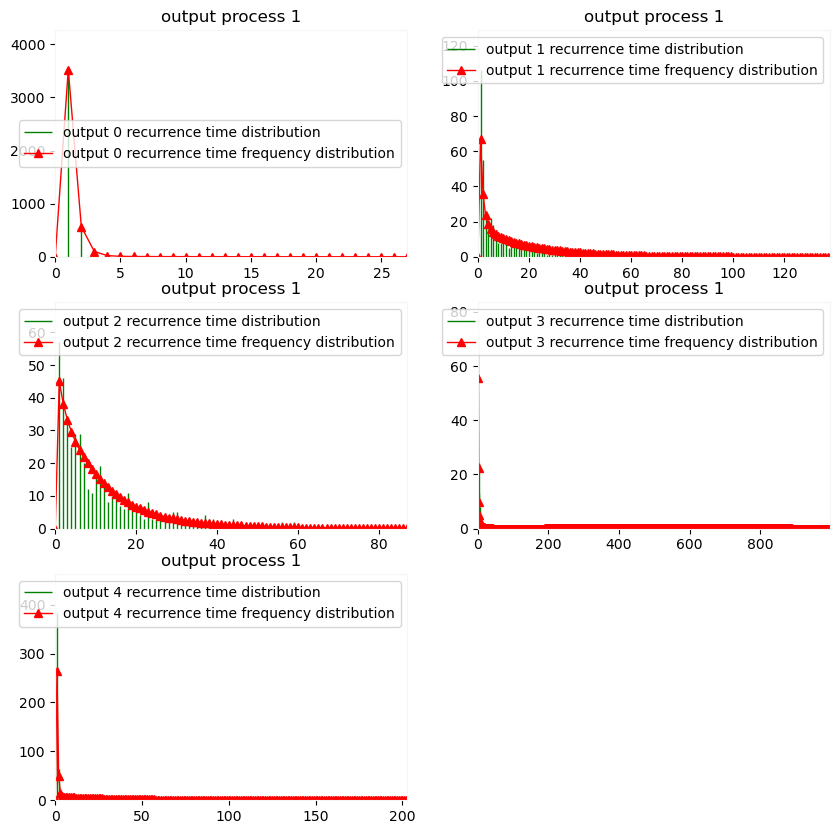

In [31]:
hsmc_est.plot("Recurrence", 1)


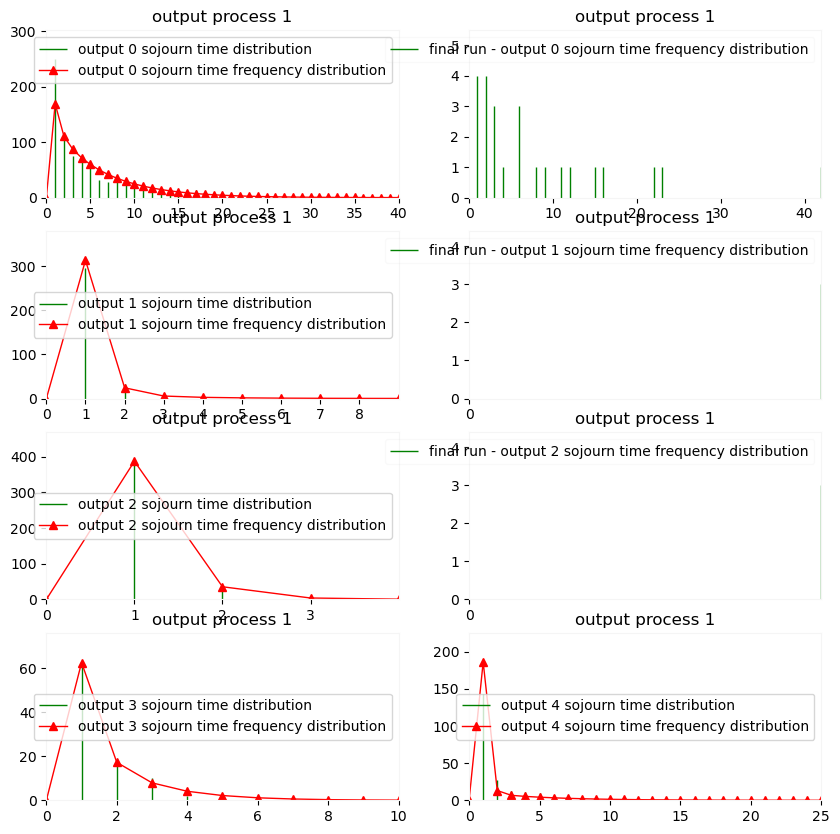

In [32]:
hsmc_est.plot("Sojourn", 1)


Note that you may also plot figures individually (and not as a collection of figures)

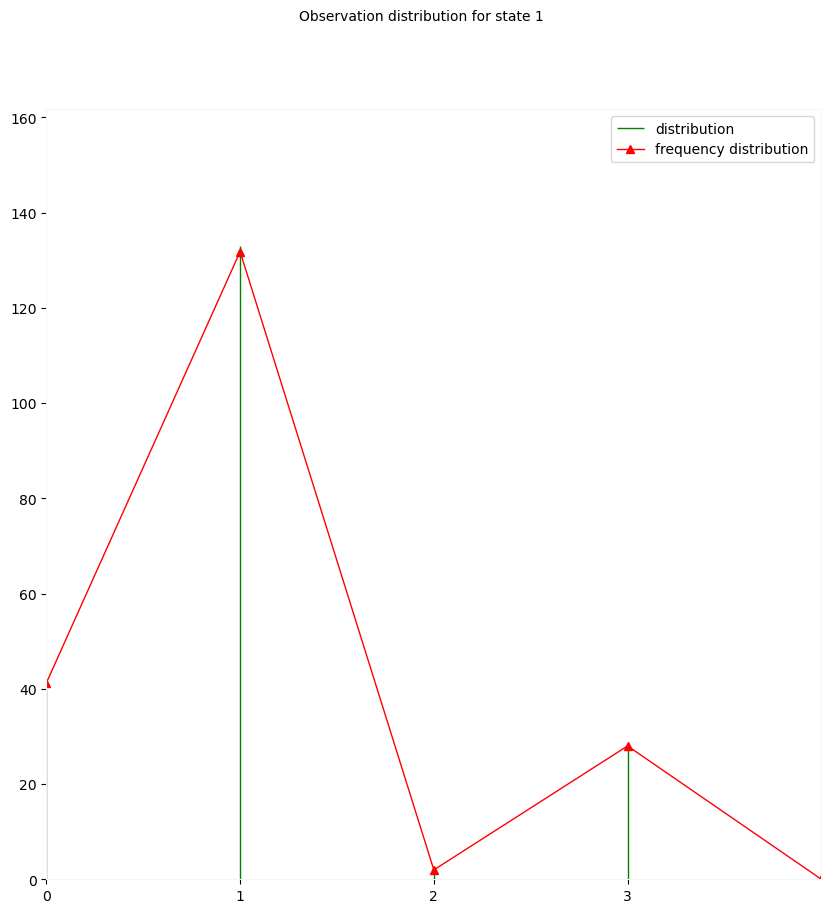

In [33]:
from openalea.sequence_analysis import seq_map
hsmc_est.extract(seq_map['Observation'],1,1).plot(Title="Observation distribution for state 1")

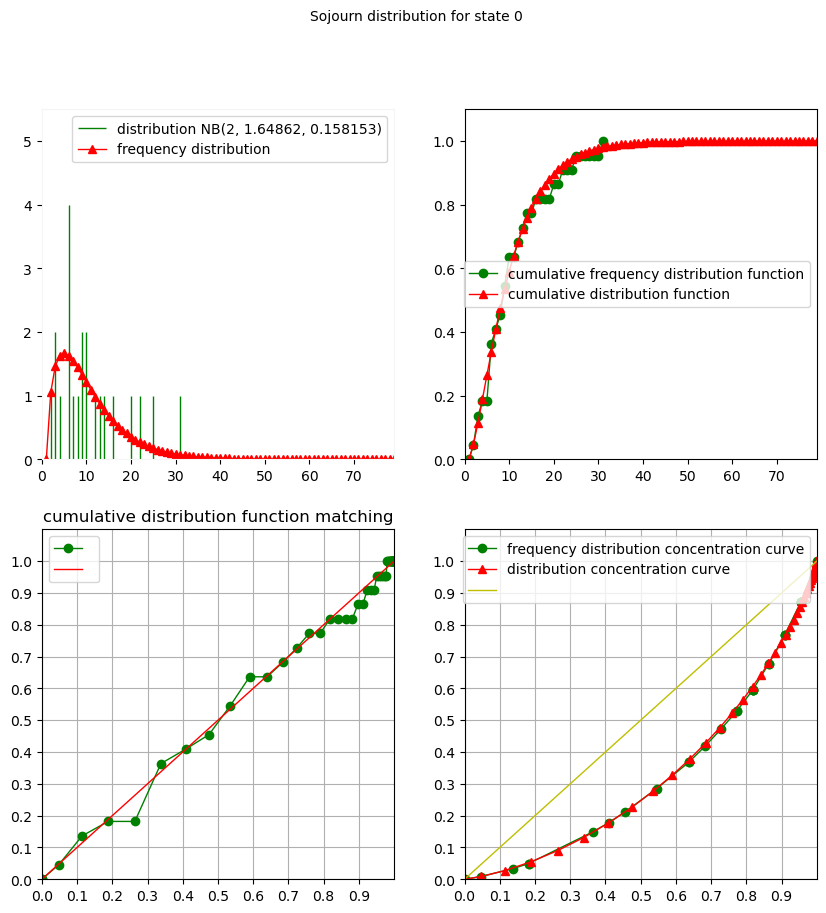

In [34]:
hsmc_est.extract(seq_map['Sojourn'],0,0).plot(Title="Sojourn distribution for state 0")

### Reestimate from true model

In [35]:
hsmc_est = Estimate(obs, "HIDDEN_SEMI-MARKOV", hsmc_est, Nbiteration=300)   
print(hsmc_est.display())

HIDDEN_SEMI-MARKOV_CHAIN

6 STATES

INITIAL_PROBABILITIES
0.73737      1e-05        0.227942     0.034658     1e-05        1e-05        

TRANSITION_PROBABILITIES
0            0.495828     1e-05        0.504142     1e-05        1e-05        
1e-05        0            1e-05        1e-05        0.99996      1e-05        
1e-05        1e-05        0            0.99996      1e-05        1e-05        
1e-05        1e-05        1e-05        0            0.842339     0.157631     
1e-05        1e-05        1e-05        1e-05        0            0.99996      
0.999766     1.31243e-05  0.000201331  1e-05        1e-05        0            

recurrent class: states 0 1 2 3 4 5

time up to the first occurrence of state 0 distribution
mean: 120.693   median: 0   mode: 0
variance: 47468.1   standard deviation: 217.872   lower quartile: 0   upper quartile: 258

time up to the first occurrence of state 0 frequency distribution - sample size: 22
mean: 0   median: 0   mode: 0
variance: 0   standard devia

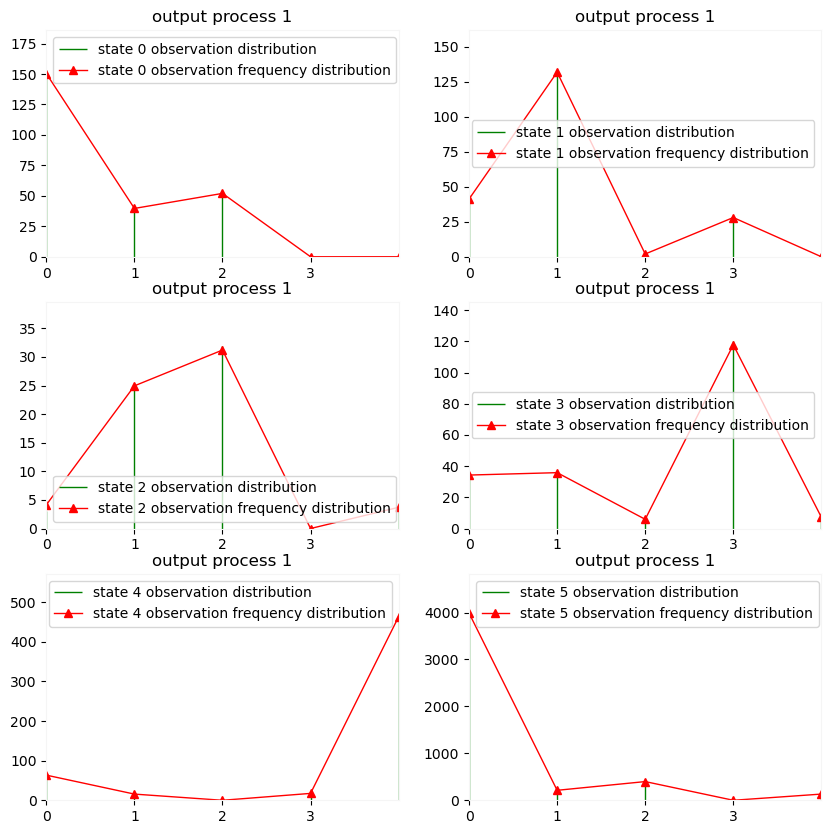

In [36]:
hsmc_est.plot("Observation", 1)


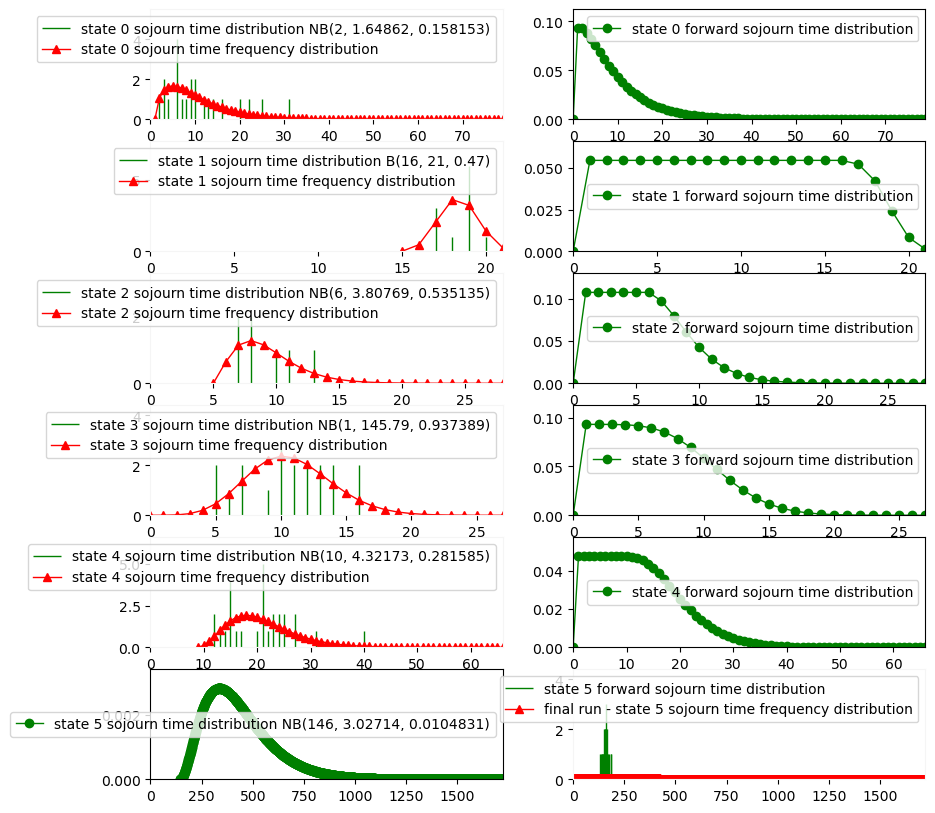

In [37]:
hsmc_est.plot("Sojourn", 0)

# State restoration: Viterbi algorithm

In [38]:
restored = hsmc_est.state_sequence_computation(obs, True)

Percentages of correct restoration per state value

In [39]:
# number of values in state 0
v0 = len([i for s in range(len(seq)) for i in range(len(seq[s])) if seq[s][i][0] == 0])
# number of values in state 0 with restored state 1
m0 = len([i for s in range(len(seq)) for i in range(len(seq[s])) if seq[s][i][0] == 0 and restored[s][i][0] == 0])
# number of values in state 1
v1 = len([i for s in range(len(seq)) for i in range(len(seq[s])) if seq[s][i][0] == 1])
# number of values in state 0 with restored state 1
m1 = len([i for s in range(len(seq)) for i in range(len(seq[s])) if seq[s][i][0] == 1 and restored[s][i][0] == 1])
# number of values in state 2
v2 = len([i for s in range(len(seq)) for i in range(len(seq[s])) if seq[s][i][0] == 2])
# number of values in state 2 with restored state 2
m2 = len([i for s in range(len(seq)) for i in range(len(seq[s])) if seq[s][i][0] == 2 and restored[s][i][0] == 2])
print((m0/v0, m1/v1, m2/v2))


(0.9590163934426229, 0.9846153846153847, 0.9846153846153847)
